In [36]:
import pandas as pd
from glob import glob
import os
import shutil
import matplotlib.pyplot as plt
import numpy as np
from tools import clean_folder

In [30]:
from pathlib import Path
os.chdir(os.getcwd())
print(os.getcwd())
# The pdbs after cleaning outliers
folder_path = Path('Results/activation_segments/Mustang_with_singlechain')

#Get the valid names of pdbs in the folder
valid_names = [f.stem for f in folder_path.iterdir() if f.is_file()]

print(len(valid_names))

/data/student/xujia/auto_newnew
2338


In [31]:
cols=["query","target","fident","alnlen","rmsd","t","u","qaln","taln"]
df = pd.read_csv("Results.m8", sep='\t', header=None, names=cols)
df=df[df['target'].isin(valid_names)]
print(f"{df.shape[0]} alignments have been found by foldseek.")

2338 alignments have been found by foldseek.


In [34]:
# -* 表示 DFG 和 APE 之间可以有 0 个、1 个或多个连字符
pattern = r'DFG-*APE'

condition = (
    df['qaln'].str.contains(pattern, case=False, na=False, regex=True) | 
    df['taln'].str.contains(pattern, case=False, na=False, regex=True)
)

filtered_df = df[condition]
no_dfg_ape = df[~condition]

print(f"{filtered_df.shape[0]} alignments have both DFG and APE motifs properly aligned (allowing gaps).")
print(f"{no_dfg_ape.shape[0]} alignments do not have both DFG and APE motifs properly aligned.")
print(f"{no_dfg_ape['target'].tolist()} do not have both DFG and APE motifs properly aligned.")

2062 alignments have both DFG and APE motifs properly aligned (allowing gaps).
276 alignments do not have both DFG and APE motifs properly aligned.
['6NSQ_A', '7P3V_B', '6P7G_B', '5DA3_A', '5CEN_A', '1YI6_B', '4UXQ_A', '5ZV2_A', '8E1X_A', '4J95_A', '8UDU_B', '4K11_A', '4GVJ_A', '5BMM_A', '1IEP_A', '1OPJ_B', '4GIH_A', '6HD4_B', '2E2B_A', '3NYX_A', '3PYY_A', '3U4W_A', '6HD6_A', '7NG7_A', '1IEP_B', '2E2B_B', '2HCK_A', '3IK3_A', '3MSS_D', '5KHW_B', '5R9H_A', '6NPE_A', '1BMK_A', '1YQJ_A', '2HYY_A', '5RA6_A', '6C7Y_A', '6HD6_B', '8JN8_A', '3K5V_B', '4YC8_B', '5F1Z_A', '5R8X_A', '5R9I_A', '5R9L_A', '5R9W_A', '5R9Y_A', '5RA2_A', '6NPV_A', '2HIW_B', '2HYY_D', '2HZI_A', '3QRI_B', '4EHZ_C', '5KHW_A', '5R90_A', '5R9G_A', '5R9J_A', '5R9P_A', '5R9X_A', '5RA0_A', '5RA4_A', '5RA5_A', '6SO4_A', '6SOI_A', '6SOT_A', '2ZB0_A', '3IK3_B', '3MS9_A', '3MS9_B', '3MSS_B', '3OY3_A', '4LG4_C', '5HX8_B', '5R94_A', '5R96_A', '5R99_A', '5R9E_A', '5R9F_A', '5R9M_A', '5R9R_A', '5RA3_A', '6OVA_A', '6S9W_A', '6SO2_A', '

In [35]:
#this is the list stored pdbs with correct alignment of dfg and ape
filtered_df["target"].values

array(['6NYB_A', '7M0Y_A', '5VAM_A', ..., '6R8J_A', '6YTD_A', '6YTE_C'],
      dtype=object)

In [37]:
import mdtraj as md
import os
from tqdm import tqdm

def strip_to_ca(pdb_path, start_residue, end_residue):
    """提取 C-alpha 原子"""
    pdb = md.load(pdb_path)
    # 获取指定范围内且名称为 CA 的原子索引
    atom_indices = [
        atom.index 
        for res in pdb.top._residues[start_residue:end_residue] 
        for atom in res.atoms 
        if atom.name == "CA"
    ]
    return pdb.atom_slice(atom_indices)

def process_selected_pdbs(pdb_dir, target_dir, valid_names):
    """
    根据给定的文件名列表处理 PDB
    :param pdb_dir: 原始 PDB 所在文件夹
    :param target_dir: 结果保存文件夹
    :param valid_names: 包含文件名的列表 (例如: ['1a1b.pdb', '2c3d.pdb'])
    """
    os.makedirs(target_dir, exist_ok=True)
    clean_folder(target_dir)  # 清空目标文件夹
    success_count = 0
    
    # 直接遍历你提供的列表
    for pdb_name in tqdm(valid_names, desc="Extract CA segments"):
        # 拼接完整的文件路径
        fp = os.path.join(pdb_dir, f"{pdb_name}.pdb")
        #print(f"Running on file:{pdb_name}")
        # 检查文件物理上是否存在
        if not os.path.exists(fp):
            # print(f"警告: 文件 {pdb_name} 不在路径 {pdb_dir} 中，跳过")
            continue
            
        try:
            # 1. 加载并获取序列
            pdb = md.load(fp)
            # 提取单字母序列
            sequence = "".join([res.code for res in pdb.top.residues])
            
            # 2. 定位 DFG 和 APE
            dfg_idx = sequence.find("DFG")
            ape_idx = sequence.find("APE")
            
            # 3. 验证基序是否存在
            if dfg_idx == -1 or ape_idx == -1:
                continue
            
            # 4. 提取并保存 (APE 后面取 3 个残基包含完整的 A-P-E)
            stripped = strip_to_ca(fp, dfg_idx, ape_idx + 3)
            
            save_path = os.path.join(target_dir, f"{pdb_name}.pdb")
            stripped.save(save_path)
            success_count += 1
            
        except Exception as e:
            print(f"Error in running {pdb_name}: {e}")

    print(f"\n Sucessfully extracted {success_count} CA segments. \n Strored in: {target_dir}")

# --- 使用示例 ---
if __name__ == "__main__":
    # 假设这是你之前筛选好的文件名列表
    my_valid_pdbs = filtered_df["target"].values
    
    # 路径配置
    source_folder = "Results/activation_segments/Mustang_with_singlechain_withoutlier"
    output_folder = "Results/activation_segments/CA_segments/mustang_endsAlignment"
    
    process_selected_pdbs(source_folder, output_folder, my_valid_pdbs)

Extract CA segments:  15%|█▍        | 299/2062 [00:54<05:48,  5.07it/s]

Error in running 3ZMM_A: sequence item 273: expected str instance, NoneType found


Extract CA segments:  34%|███▍      | 710/2062 [02:13<04:15,  5.29it/s]

Error in running 3ZMM_B: sequence item 274: expected str instance, NoneType found


Extract CA segments:  56%|█████▌    | 1150/2062 [03:41<03:18,  4.60it/s]

Error in running 7SJ3_A: sequence item 0: expected str instance, NoneType found


Extract CA segments: 100%|██████████| 2062/2062 [06:56<00:00,  4.95it/s]


 Sucessfully extracted 2059 CA segments. 
 Strored in: Results/activation_segments/CA_segments/mustang_endsAlignment


In [38]:
#Crete template.pdb with only ca atoms
source_folder = "./"
output_folder = "./template_pdb"
    
process_selected_pdbs(source_folder, output_folder, ["6UAN_chainD"])

Extract CA segments: 100%|██████████| 1/1 [00:00<00:00,  4.81it/s]


 Sucessfully extracted 1 CA segments. 
 Strored in: ./template_pdb


In [39]:
def count_pdb_files(directory):
    directory = os.path.join(directory, '')

    pdb_files = glob(os.path.join(directory, '*.pdb'))

    return len(pdb_files)

pdb_directory = 'Results/activation_segments/CA_segments/mustang_endsAlignment'

pdb_count = count_pdb_files(pdb_directory)

print(f"There are {pdb_count} PDB files in the directory '{pdb_directory}'.")

There are 2059 PDB files in the directory 'Results/activation_segments/CA_segments/mustang_endsAlignment'.


################################################################################
RUNNING TUKEY'S OUTLIER DETECTION WITH k = 1.5
################################################################################
Found 2059 PDB files in Results/activation_segments/CA_segments/mustang_endsAlignment


Analyzing CA segments:   0%|          | 0/2059 [00:00<?, ?it/s]

Analyzing CA segments: 100%|██████████| 2059/2059 [00:02<00:00, 689.26it/s]



ORIGINAL DATASET STATISTICS
Total structures: 2059
CA counts - Min: 16, Max: 36, Mean: 27.93, Median: 28.00

TUKEY'S OUTLIER DETECTION - CA COUNTS
Q1: 27.00, Q3: 30.00, IQR: 3.00
Lower bound: 22.50, Upper bound: 34.50
Outliers found: 48 out of 2059 (2.3%)
CA count outliers:
  - 5I3O_B.pdb: 36 CA atoms
  - 8PT9_B.pdb: 22 CA atoms
  - 8PTA_B.pdb: 22 CA atoms
  - 3FL4_A.pdb: 21 CA atoms
  - 5TE0_A.pdb: 36 CA atoms
  - 5XYX_A.pdb: 22 CA atoms
  - 3FKN_A.pdb: 22 CA atoms
  - 4J7B_D.pdb: 17 CA atoms
  - 8GMC_B.pdb: 36 CA atoms
  - 8FX4_D.pdb: 16 CA atoms
  - 1AD5_A.pdb: 19 CA atoms
  - 3FLN_C.pdb: 22 CA atoms
  - 3E93_A.pdb: 22 CA atoms
  - 3FMN_A.pdb: 21 CA atoms
  - 2GTM_A.pdb: 21 CA atoms
  - 3FLW_A.pdb: 22 CA atoms
  - 6EMH_B.pdb: 22 CA atoms
  - 6EMH_A.pdb: 22 CA atoms
  - 6DTL_B.pdb: 21 CA atoms
  - 5I3O_A.pdb: 36 CA atoms
  - 3FKO_A.pdb: 22 CA atoms
  - 8GMD_A.pdb: 36 CA atoms
  - 4W9X_A.pdb: 36 CA atoms
  - 3FPM_A.pdb: 18 CA atoms
  - 3V6S_A.pdb: 22 CA atoms
  - 4WSQ_B.pdb: 36 CA at

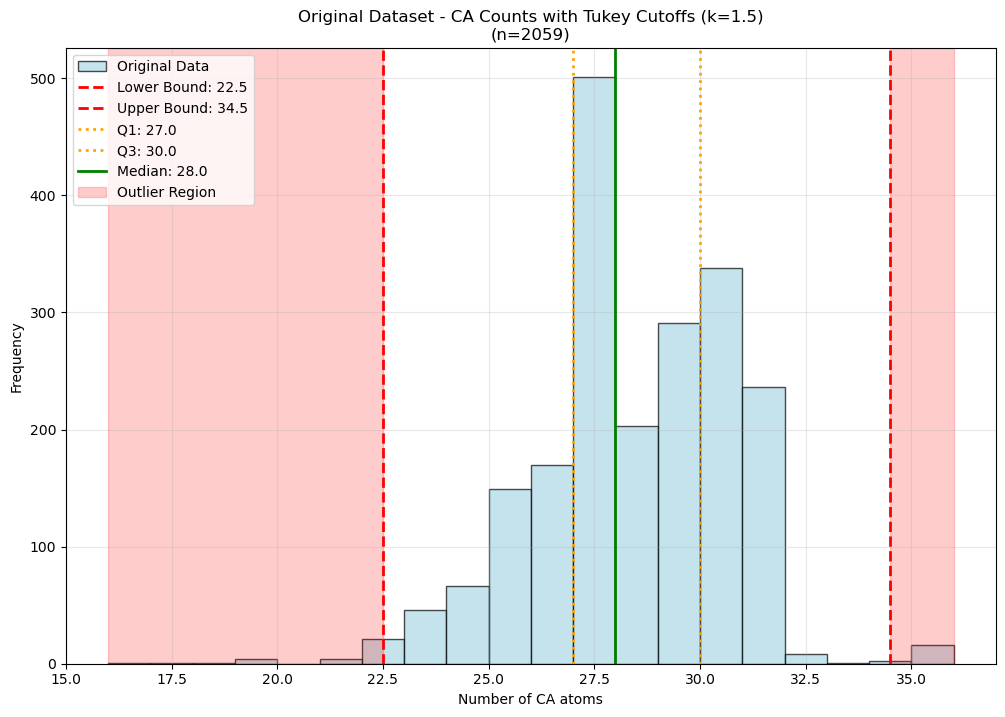

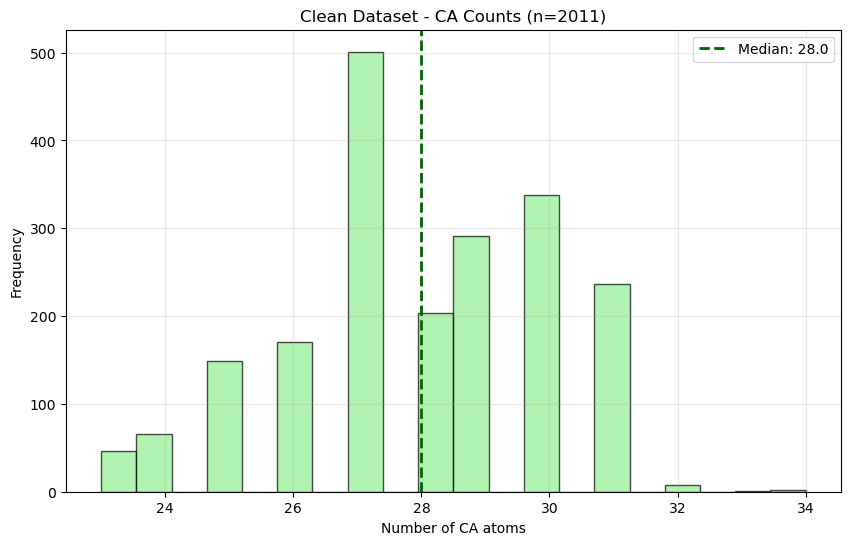

/tmp/ipykernel_3401013/2168540461.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(box_data_ca, labels=['Original', 'Clean'], patch_artist=True)


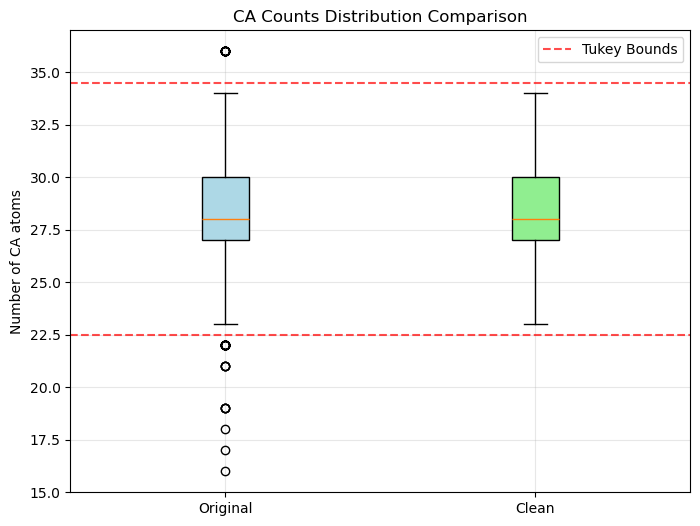


Copying clean structures to: Results/activation_segments/CA_segments/mustang_endsAlignment_cleaned


Copying clean files: 100%|██████████| 2011/2011 [00:00<00:00, 5331.72it/s]

Created clean directory with 2011 structures
Outlier information saved to: outliers_removed_k1.5.csv
Clean dataset information saved to: clean_dataset_k1.5.csv

Final Results:
- Original dataset: 2059 structures
- Clean dataset: 2011 structures
- Outliers removed: 48 structures
- Outlier percentage: 2.3%
- Clean structures saved to: Results/activation_segments/CA_segments/mustang_endsAlignment_cleaned


In [41]:
import os
import numpy as np
import matplotlib.pyplot as plt
import mdtraj as md
from glob import glob
from tqdm import tqdm
import pandas as pd
from scipy import stats
import shutil

# Perform Tukey's method to detect outliers based on the interquartile range (IQR)
def tukey_outlier_detection(data, k=1.5):
   
    data = np.array(data)
    
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - k * IQR
    upper_bound = Q3 + k * IQR
    
    outlier_indices = np.where((data < lower_bound) | (data > upper_bound))[0]
    
    return outlier_indices, lower_bound, upper_bound, Q1, Q3, IQR

# Create histograms and boxplot to visualize CA atom count distributions and outliers
def create_plots(original_ca, clean_ca, output_dir, k_factor, ca_lower, ca_upper, ca_Q1, ca_Q3):
    plt.figure(figsize=(12, 8))
    
    # Histogram of original CA counts with Tukey bounds
    n, bins, patches = plt.hist(original_ca, bins=20, alpha=0.7, color='lightblue', edgecolor='black', label='Original Data')

    plt.axvline(x=ca_lower, color='red', linestyle='--', linewidth=2, label=f'Lower Bound: {ca_lower:.1f}')
    plt.axvline(x=ca_upper, color='red', linestyle='--', linewidth=2, label=f'Upper Bound: {ca_upper:.1f}')

    plt.axvline(x=ca_Q1, color='orange', linestyle=':', linewidth=2, label=f'Q1: {ca_Q1:.1f}')
    plt.axvline(x=ca_Q3, color='orange', linestyle=':', linewidth=2, label=f'Q3: {ca_Q3:.1f}')

    median_ca = np.median(original_ca)
    plt.axvline(x=median_ca, color='green', linestyle='-', linewidth=2, label=f'Median: {median_ca:.1f}')

    plt.axvspan(min(original_ca), ca_lower, alpha=0.2, color='red', label='Outlier Region')
    plt.axvspan(ca_upper, max(original_ca), alpha=0.2, color='red')
    
    plt.xlabel('Number of CA atoms')
    plt.ylabel('Frequency')
    plt.title(f'Original Dataset - CA Counts with Tukey Cutoffs (k={k_factor})\n(n={len(original_ca)})')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig(os.path.join(output_dir, f'original_ca_distribution_with_cutoffs_k{k_factor}.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()

    # Histogram for clean CA-only structures
    plt.figure(figsize=(10, 6))
    
    n, bins, patches = plt.hist(clean_ca, bins=20, alpha=0.7, color='lightgreen', edgecolor='black')

    clean_median = np.median(clean_ca)
    plt.axvline(x=clean_median, color='darkgreen', linestyle='--', linewidth=2, 
                label=f'Median: {clean_median:.1f}')
    
    plt.xlabel('Number of CA atoms')
    plt.ylabel('Frequency')
    plt.title(f'Clean Dataset - CA Counts (n={len(clean_ca)})')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig(os.path.join(output_dir, f'clean_ca_distribution_k{k_factor}.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()

    
    plt.figure(figsize=(8, 6))
    
    box_data_ca = [original_ca, clean_ca]
    bp = plt.boxplot(box_data_ca, labels=['Original', 'Clean'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightgreen')
    plt.ylabel('Number of CA atoms')
    plt.title('CA Counts Distribution Comparison')
    plt.grid(True, alpha=0.3)

    plt.axhline(y=ca_lower, color='red', linestyle='--', alpha=0.7, label='Tukey Bounds')
    plt.axhline(y=ca_upper, color='red', linestyle='--', alpha=0.7)
    plt.legend()
    
    plt.savefig(os.path.join(output_dir, f'ca_boxplot_comparison_k{k_factor}.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()

# Main function: analyze CA-only PDB segments and remove outliers based on CA count
def analyze_ca_segments_with_outlier_removal(ca_segments_dir, k_factor=1.5):

    pdb_files = glob(os.path.join(ca_segments_dir, "*.pdb"))
    print(f"Found {len(pdb_files)} PDB files in {ca_segments_dir}")

    file_info = []

    # Count the number of atoms in each PDB (should all be Cα atoms)
    for pdb_file in tqdm(pdb_files, desc="Analyzing CA segments"):
        try:
            traj = md.load(pdb_file)
            
            num_ca = traj.n_atoms
            
            file_info.append({
                'filename': os.path.basename(pdb_file),
                'filepath': pdb_file,
                'ca_count': num_ca
            })
                
        except Exception as e:
            print(f"Error processing {pdb_file}: {e}")

    df = pd.DataFrame(file_info)

    ca_counts = df['ca_count'].values
    
    print(f"\n{'='*60}")
    print("ORIGINAL DATASET STATISTICS")
    print(f"{'='*60}")
    print(f"Total structures: {len(df)}")
    print(f"CA counts - Min: {ca_counts.min()}, Max: {ca_counts.max()}, Mean: {ca_counts.mean():.2f}, Median: {np.median(ca_counts):.2f}")

    # Run Tukey outlier detection
    ca_outlier_indices, ca_lower, ca_upper, ca_Q1, ca_Q3, ca_IQR = tukey_outlier_detection(ca_counts, k=k_factor)
    
    print(f"\n{'='*60}")
    print("TUKEY'S OUTLIER DETECTION - CA COUNTS")
    print(f"{'='*60}")
    print(f"Q1: {ca_Q1:.2f}, Q3: {ca_Q3:.2f}, IQR: {ca_IQR:.2f}")
    print(f"Lower bound: {ca_lower:.2f}, Upper bound: {ca_upper:.2f}")
    print(f"Outliers found: {len(ca_outlier_indices)} out of {len(ca_counts)} ({len(ca_outlier_indices)/len(ca_counts)*100:.1f}%)")
    
    if len(ca_outlier_indices) > 0:
        print("CA count outliers:")
        for idx in ca_outlier_indices:
            print(f"  - {df.iloc[idx]['filename']}: {df.iloc[idx]['ca_count']} CA atoms")

    clean_df = df.drop(df.index[ca_outlier_indices]).reset_index(drop=True)
    
    print(f"\n{'='*60}")
    print("OUTLIER REMOVAL BASED ON CA COUNTS")
    print(f"{'='*60}")
    print(f"Outliers to remove: {len(ca_outlier_indices)} out of {len(df)} ({len(ca_outlier_indices)/len(df)*100:.1f}%)")
    print(f"Clean dataset size: {len(clean_df)} structures")

    if len(ca_outlier_indices) > 0:
        print("\nStructures being removed as outliers:")
        outlier_df = df.iloc[ca_outlier_indices]
        for _, row in outlier_df.iterrows():
            print(f"  - {row['filename']}: {row['ca_count']} CA atoms")

    clean_ca_counts = clean_df['ca_count'].values
    
    print(f"\n{'='*60}")
    print("CLEAN DATASET STATISTICS")
    print(f"{'='*60}")
    print(f"Total structures: {len(clean_df)}")
    print(f"CA counts - Min: {clean_ca_counts.min()}, Max: {clean_ca_counts.max()}, Mean: {clean_ca_counts.mean():.2f}, Median: {np.median(clean_ca_counts):.2f}")
    
    create_plots(ca_counts, clean_ca_counts, ca_segments_dir, k_factor, ca_lower, ca_upper, ca_Q1, ca_Q3)

    clean_dir = "Results/activation_segments/CA_segments/mustang_endsAlignment_cleaned"

    if os.path.exists(clean_dir):
        shutil.rmtree(clean_dir)
    os.makedirs(clean_dir)
    
    print(f"\nCopying clean structures to: {clean_dir}")
    for _, row in tqdm(clean_df.iterrows(), total=len(clean_df), desc="Copying clean files"):
        src = row['filepath']
        dst = os.path.join(clean_dir, row['filename'])
        shutil.copy2(src, dst)
    
    print(f"Created clean directory with {len(clean_df)} structures")

    results = {
        'original_df': df,
        'clean_df': clean_df,
        'outlier_indices': ca_outlier_indices,
        'ca_outlier_info': {
            'indices': ca_outlier_indices,
            'bounds': (ca_lower, ca_upper),
            'quartiles': (ca_Q1, ca_Q3),
            'IQR': ca_IQR
        },
        'k_factor': k_factor
    }

    if len(ca_outlier_indices) > 0:
        outlier_df = df.iloc[ca_outlier_indices].copy()
        outlier_df.to_csv(os.path.join(ca_segments_dir, f"outliers_removed_k{k_factor}.csv"), index=False)
        print(f"Outlier information saved to: outliers_removed_k{k_factor}.csv")

    clean_df.to_csv(os.path.join(ca_segments_dir, f"clean_dataset_k{k_factor}.csv"), index=False)
    print(f"Clean dataset information saved to: clean_dataset_k{k_factor}.csv")
    
    return results

# Entry point: run analysis using a default CA segment directory
if __name__ == "__main__":

    ca_dir = "Results/activation_segments/CA_segments/mustang_endsAlignment"

    k_factor = 1.5
    
    print(f"{'#'*80}")
    print(f"RUNNING TUKEY'S OUTLIER DETECTION WITH k = {k_factor}")
    print(f"{'#'*80}")
    
    results = analyze_ca_segments_with_outlier_removal(ca_dir, k_factor=k_factor)
    
    print(f"\nFinal Results:")
    print(f"- Original dataset: {len(results['original_df'])} structures")
    print(f"- Clean dataset: {len(results['clean_df'])} structures")
    print(f"- Outliers removed: {len(results['outlier_indices'])} structures")
    print(f"- Outlier percentage: {len(results['outlier_indices'])/len(results['original_df'])*100:.1f}%")
    print(f"- Clean structures saved to: Results/activation_segments/CA_segments/mustang_endsAlignment_cleaned")

### May have something to improve, cause it will change all pdb to the same length, may loose too many original information

In [43]:
"""
This script performs geometric fitting of C-alpha atom traces using cubic spline interpolation combined with arc-length reparameterization. Each input structure is resampled to match the number and spacing of C-alpha atoms in a reference template. The fitted coordinates are written into the template structure and saved to a target directory. This ensures all output structures are of uniform length and alignment-ready for downstream analysis.

"""
from Bio import PDB
import tempfile
from scipy.interpolate import interp1d
# Fitting function to resample CA trace using cubic spline interpolation and arc length parameterization
def fitting_code(fp_or_traj, save_path):
    # Helper function to read structure from file path or md.Trajectory
    def read_structure(input_data):
        if isinstance(input_data, str):
            parser = PDB.PDBParser(QUIET=True)
            structure = parser.get_structure('structure', input_data)
        elif isinstance(input_data, md.Trajectory):
            with tempfile.NamedTemporaryFile(suffix=".pdb", delete=False) as tmpfile:
                input_data.save(tmpfile.name)
                tmpfile.close()
                parser = PDB.PDBParser(QUIET=True)
                structure = parser.get_structure('structure', tmpfile.name)
            os.unlink(tmpfile.name)
        else:
            raise ValueError("Unsupported input type. Provide a file path or md.Trajectory.")
        return structure[0]

    # Load the template model and count CA atoms
    template_model = read_structure('template_pdb/6UAN_chainD.pdb')
    Nnew = len([atom for atom in template_model.get_atoms() if atom.get_id() == 'CA'])

    # Load the target model and extract CA coordinates
    my_model = read_structure(fp_or_traj)
    atom_list = [atom for atom in my_model.get_atoms() if atom.get_id() == 'CA']

    avg = np.array([atom.coord for atom in atom_list])
    n = len(atom_list)

    # Fit cubic splines for x, y, z separately
    dims = ['x', 'y', 'z']
    fits = {}
    for j, dim in enumerate(dims):
        fits[dim] = interp1d(np.arange(n), avg[:, j], kind='cubic', fill_value='extrapolate')

    # Compute arc length along the curve defined by the spline
    X = np.arange(0, n - 1, 0.1) 
    dYdX = {dim: np.gradient(fits[dim](X)) for dim in dims}
    Y = np.sqrt(sum(np.square(dYdX[dim]) for dim in dims))
    L = np.trapz(Y, X)

    # Resample to Nnew points spaced uniformly in arc length
    Li = np.linspace(0, L, Nnew)

    flen = np.array([np.trapz(Y[:ibig], X[:ibig]) for ibig in range(1, len(X))])

    pt = np.zeros(Nnew, dtype=int)
    for i in range(Nnew):
        pt[i] = np.argmin(np.abs(flen - Li[i]))

    # Generate new coordinates from the fitted splines
    new_coords = np.array([[fits[dim](X[pt[i]]) for dim in dims] for i in range(Nnew)])

    # Replace the coordinates of CA atoms in the template with fitted values
    ca_index = 0
    for atom in template_model.get_atoms():
        if atom.get_id() == 'CA':
            atom.set_coord(new_coords[ca_index])
            ca_index += 1

    try:
        with open(save_path, "w") as file:
            io = PDB.PDBIO()
            io.set_structure(template_model)
            io.save(file)
        print(f'Successfully saved the structure to {save_path}')
    except Exception as e:
        print(f"Error during file save: {e}")


# Set input and output directories
input_dir = "Results/activation_segments/CA_segments/mustang_endsAlignment_cleaned"
output_dir = "Results/fitted_matlab_segments/mustang_endsAlignment_cleaned/"

os.makedirs(output_dir, exist_ok=True)
clean_folder(output_dir)  # Ensure the output directory is empty before saving new files
print(f"\n{'#'*80}")
print(f"PROCESSING CLEANED STRUCTURES WITH FITTING")
print(f"{'#'*80}")
print(f"Input:  {input_dir}")
print(f"Output: {output_dir}")

# Loop through all PDB files in input directory and apply the fitting
for file_name in os.listdir(input_dir):
    if file_name.endswith('.pdb'):
        input_file_path = os.path.join(input_dir, file_name)
        output_file_path = os.path.join(output_dir, file_name)
        fitting_code(input_file_path, output_file_path) 


################################################################################
PROCESSING CLEANED STRUCTURES WITH FITTING
################################################################################
Input:  Results/activation_segments/CA_segments/mustang_endsAlignment_cleaned
Output: Results/fitted_matlab_segments/mustang_endsAlignment_cleaned/
Successfully saved the structure to Results/fitted_matlab_segments/mustang_endsAlignment_cleaned/6VNL_B.pdb
Successfully saved the structure to Results/fitted_matlab_segments/mustang_endsAlignment_cleaned/8AHG_A.pdb
Successfully saved the structure to Results/fitted_matlab_segments/mustang_endsAlignment_cleaned/7E75_A.pdb
Successfully saved the structure to Results/fitted_matlab_segments/mustang_endsAlignment_cleaned/8V2F_C.pdb
Successfully saved the structure to Results/fitted_matlab_segments/mustang_endsAlignment_cleaned/3D83_A.pdb
Successfully saved the structure to Results/fitted_matlab_segments/mustang_endsAlignment_cleaned/4NU1_A.pd

Saved figure to Results/fitted_matlab_segments/mustang_endsAlignment_cleaned/2JFL_A_CA_alignment.png


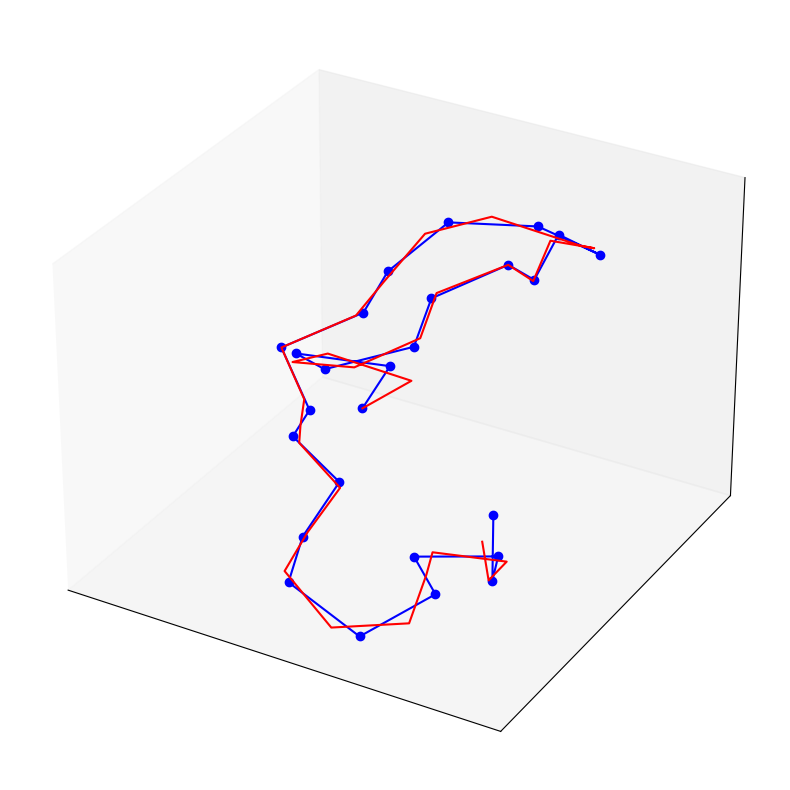

In [44]:

xyz = md.load("Results/activation_segments/CA_segments/mustang_endsAlignment_cleaned/1GNG_A.pdb")

DFG = xyz.top.to_fasta()[0].find("DFG")
APE = xyz.top.to_fasta()[0].find("APE")+2
atoms = sum([[atom.index for atom in res.atoms if atom.name == "CA"] for res in xyz.top._residues[:]],[])

coords = xyz.xyz[0,atoms].T
x = coords[0]
y = coords[1]
z = coords[2]
new_coords = md.load("Results/fitted_matlab_segments/mustang_endsAlignment_cleaned/1GNG_A.pdb")

atoms = sum([[atom.index for atom in res.atoms if atom.name == "CA"] for res in new_coords.top._residues[:]],[])
new_coords = new_coords.xyz[0,atoms].T
xp = new_coords[0]
yp = new_coords[1]
zp = new_coords[2]

fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
ax.plot3D(x,y,z, 'blue',marker="o")
ax.plot3D(xp, yp, zp, 'red')
plt.tick_params(bottom=False, top=False, labelbottom=False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

pdb_name = os.path.splitext(os.path.basename("Results/fitted_matlab_segments/mustang_endsAlignment_cleaned/2JFL_A.pdb"))[0]
output_path = f"Results/fitted_matlab_segments/mustang_endsAlignment_cleaned/{pdb_name}_CA_alignment.png"

plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Saved figure to {output_path}")

In [45]:
from pymol import cmd
from glob import glob
import os

# need to improve the logic of cleaning outlier, to be continued




# Print the atoms (resi, resn, name) and total count of a given selection
def print_selection_details(selection_name):
    print(f"Details for selection: {selection_name}")
    cmd.iterate(selection_name, "print(resi, resn, name)")
    count = cmd.count_atoms(selection_name)
    print(f"Number of atoms in {selection_name}: {count}")

# Main function to assess alignment of structure ends using RMSD and Euclidean distance
def process_ends_alignment(input_dir, output_dir):

    cmd.reinitialize()

    reference_pdb = "6UAN_chainD_40.pdb"
    cmd.load(reference_pdb, "6UAN_chainD")

    # Define selections for reference CA atoms
    cmd.select("6UAN_chainD_first_atom", "6UAN_chainD and resi 594 and name CA")
    cmd.select("6UAN_chainD_last_atom",  "6UAN_chainD and resi 623 and name CA")
    print_selection_details("6UAN_chainD_first_atom")
    print_selection_details("6UAN_chainD_last_atom")

    # Define selections for reference CA triplets (for RMSD calculation)
    cmd.select("6UAN_chainD_first3", "6UAN_chainD and resi 594-596 and name CA")
    cmd.select("6UAN_chainD_last3",  "6UAN_chainD and resi 621-623 and name CA")
    print_selection_details("6UAN_chainD_first3")
    print_selection_details("6UAN_chainD_last3")

    euclid_first_atom = []   
    euclid_last_atom  = []   
    rmsd_first3_atoms = []  
    rmsd_last3_atoms  = []  

    # Load all fitted PDB files
    fitted_pdb_files = glob(os.path.join(input_dir, "*.pdb"))
    total_structures = len(fitted_pdb_files)
    print(f"\nProcessing Ends Alignment directory: {input_dir}")
    print(f"Found {total_structures} PDB files.\n")

    structures_with_large_euclid_first = []
    structures_with_large_euclid_last  = []

    for fitted_pdb_file in fitted_pdb_files:
        print(f"Processing file: {fitted_pdb_file}")
        pdb_code = os.path.basename(fitted_pdb_file).split('.')[0]

        cmd.load(fitted_pdb_file, pdb_code)

        # Select corresponding atoms for comparison
        cmd.select(f"{pdb_code}_first_atom", f"{pdb_code} and resi 594 and name CA")
        cmd.select(f"{pdb_code}_last_atom",  f"{pdb_code} and resi 623 and name CA")

        cmd.select(f"{pdb_code}_first3_atoms", f"{pdb_code} and resi 594-596 and name CA")
        cmd.select(f"{pdb_code}_last3_atoms",  f"{pdb_code} and resi 621-623 and name CA")

        print_selection_details(f"{pdb_code}_first_atom")
        print_selection_details(f"{pdb_code}_last_atom")
        print_selection_details(f"{pdb_code}_first3_atoms")
        print_selection_details(f"{pdb_code}_last3_atoms")

        # Calculate Euclidean distance for single atoms
        try:
            d_first = cmd.rms_cur(f"{pdb_code}_first_atom", "6UAN_chainD_first_atom", matchmaker=-1)
            print(f"Euclidean distance (first atom) for {pdb_code} vs. reference: {d_first:.2f} Å")
            euclid_first_atom.append(d_first)
            if d_first > 2:
                structures_with_large_euclid_first.append(pdb_code)
        except:
            print(f"Error calculating distance for {pdb_code}_first_atom")
            euclid_first_atom.append(np.nan)

        try:
            d_last = cmd.rms_cur(f"{pdb_code}_last_atom", "6UAN_chainD_last_atom", matchmaker=-1)
            print(f"Euclidean distance (last atom)  for {pdb_code} vs. reference: {d_last:.2f} Å")
            euclid_last_atom.append(d_last)
            if d_last > 2:
                structures_with_large_euclid_last.append(pdb_code)
        except:
            print(f"Error calculating distance for {pdb_code}_last_atom")
            euclid_last_atom.append(np.nan)

         # Calculate RMSD for first and last 3-atom segments
        try:
            rms_first3 = cmd.rms_cur(f"{pdb_code}_first3_atoms", "6UAN_chainD_first3", matchmaker=-1)
            print(f"RMSD (first 3 atoms) for {pdb_code} vs. reference: {rms_first3:.2f} Å")
            rmsd_first3_atoms.append(rms_first3)
        except:
            print(f"Error calculating RMSD for {pdb_code}_first3_atoms")
            rmsd_first3_atoms.append(np.nan)

        try:
            rms_last3 = cmd.rms_cur(f"{pdb_code}_last3_atoms", "6UAN_chainD_last3", matchmaker=-1)
            print(f"RMSD (last 3 atoms)  for {pdb_code} vs. reference: {rms_last3:.2f} Å")
            rmsd_last3_atoms.append(rms_last3)
        except:
            print(f"Error calculating RMSD for {pdb_code}_last3_atoms")
            rmsd_last3_atoms.append(np.nan)

        
    print("\nStructures with Euclidean distance > 2 Å (first atom):")
    print(structures_with_large_euclid_first)
    print("Structures with Euclidean distance > 2 Å (last atom):")
    print(structures_with_large_euclid_last)

    num_large_first = len(structures_with_large_euclid_first)
    num_large_last  = len(structures_with_large_euclid_last)
    pct_large_first = (num_large_first / total_structures) * 100 if total_structures > 0 else 0.0
    pct_large_last  = (num_large_last / total_structures) * 100 if total_structures > 0 else 0.0
    print(f"\nNumber of structures > 3 Å (first atom): {num_large_first}")
    print(f"Percentage: {pct_large_first:.2f}%")
    print(f"Number of structures > 3 Å (last atom): {num_large_last}")
    print(f"Percentage: {pct_large_last:.2f}%")

    # Identify outlier structures
    outliers_3A = []
    for i, pdb_file in enumerate(fitted_pdb_files):
        if euclid_first_atom[i] > 2.0 or euclid_last_atom[i] > 2.0:
            outliers_3A.append(pdb_file)
    
    # Copy non-outlier structures to new output directory
    os.makedirs(output_dir, exist_ok=True)
    
    copied_files = 0
    for i, pdb_file in enumerate(fitted_pdb_files):
        if pdb_file not in outliers_3A:
            shutil.copy2(pdb_file, output_dir)
            copied_files += 1
    
    print(f"\nCopied {copied_files} non-outlier structures to: {output_dir}")
    print(f"Excluded {len(outliers_3A)} outlier structures")

    # Violin plot for Euclidean distances (single atoms)
    single_atom_data = [euclid_first_atom, euclid_last_atom]
    single_atom_labels = ["First Atom", "Last Atom"]

    fig_euclid, ax_euclid = plt.subplots()
    ax_euclid.violinplot(single_atom_data)
    ax_euclid.set_xticks(np.arange(1, len(single_atom_labels) + 1))
    ax_euclid.set_xticklabels(single_atom_labels)
    ax_euclid.set_ylabel("Euclidean Distance (Å)")
    ax_euclid.set_title("Single-Atom Comparison\nEnds Alignment")
    ax_euclid.set_ylim(0, 5) 


    ax_euclid.axhline(y=3.0, color='red', linestyle=':', label='Outlier cutoff')
    ax_euclid.legend()

    euclid_plot_path = os.path.join(input_dir, "single_atom_violin.png")
    fig_euclid.savefig(euclid_plot_path, dpi=300, bbox_inches="tight")
    plt.close(fig_euclid)

    # Violin plot for RMSD (three-atom segments)
    triple_atom_data = [rmsd_first3_atoms, rmsd_last3_atoms]
    triple_atom_labels = ["First Three Atoms", "Last Three Atoms"]

    fig_rmsd, ax_rmsd = plt.subplots()
    ax_rmsd.violinplot(triple_atom_data)
    ax_rmsd.set_xticks(np.arange(1, len(triple_atom_labels) + 1))
    ax_rmsd.set_xticklabels(triple_atom_labels)
    ax_rmsd.set_ylabel("RMSD (Å)")
    ax_rmsd.set_title("Three-Atom Comparison\nEnds Alignment")
    ax_rmsd.set_ylim(0, 5)

    rmsd_plot_path = os.path.join(input_dir, "three_atom_violin.png")
    fig_rmsd.savefig(rmsd_plot_path, dpi=300, bbox_inches="tight")
    plt.close(fig_rmsd)

    # Save metrics to CSV for further analysis
    results_df = pd.DataFrame({
        "pdb_id": [os.path.basename(f).split('.')[0] for f in fitted_pdb_files],
        "euclid_first_atom": euclid_first_atom,
        "euclid_last_atom": euclid_last_atom,
        "rmsd_first3_atoms": rmsd_first3_atoms,
        "rmsd_last3_atoms": rmsd_last3_atoms
    })

    csv_path = os.path.join(input_dir, "ends_alignment_metrics.csv")
    results_df.to_csv(csv_path, index=False)
    print(f"\nRMSD and distance save: {csv_path}")


if __name__ == "__main__":

    input_directory = "Results/fitted_matlab_segments/mustang_endsAlignment_cleaned/"
    output_directory = "Results/fitted_matlab_segments/mustang_endsAlignment_cleaned_noOutliers/"
    clean_folder(output_directory)  # Ensure output directory is empty before saving new files
    process_ends_alignment(input_directory, output_directory)

Details for selection: 6UAN_chainD_first_atom
594 ASP CA
Number of atoms in 6UAN_chainD_first_atom: 1
Details for selection: 6UAN_chainD_last_atom
623 GLU CA
Number of atoms in 6UAN_chainD_last_atom: 1
Details for selection: 6UAN_chainD_first3
594 ASP CA
595 PHE CA
596 GLY CA
Number of atoms in 6UAN_chainD_first3: 3
Details for selection: 6UAN_chainD_last3
621 ALA CA
622 PRO CA
623 GLU CA
Number of atoms in 6UAN_chainD_last3: 3

Processing Ends Alignment directory: Results/fitted_matlab_segments/mustang_endsAlignment_cleaned/
Found 2011 PDB files.

Processing file: Results/fitted_matlab_segments/mustang_endsAlignment_cleaned/6VNL_B.pdb
Details for selection: 6VNL_B_first_atom
594 ASP CA
Number of atoms in 6VNL_B_first_atom: 1
Details for selection: 6VNL_B_last_atom
623 GLU CA
Number of atoms in 6VNL_B_last_atom: 1
Details for selection: 6VNL_B_first3_atoms
594 ASP CA
595 PHE CA
596 GLY CA
Number of atoms in 6VNL_B_first3_atoms: 3
Details for selection: 6VNL_B_last3_atoms
621 ALA CA
622